In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
print("All imports successful ✓")

Matplotlib is building the font cache; this may take a moment.


All imports successful ✓


In [2]:
df = pd.read_csv('../data/spending.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (806, 6)

Column names: ['Date', 'Description', 'Amount', 'Transaction Type', 'Category', 'Account Name']

Data types:
 Date                    str
Description             str
Amount              float64
Transaction Type        str
Category                str
Account Name            str
dtype: object

Null values:
 Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

First 5 rows:


,Date,Description,Amount,Transaction Type,Category,Account Name
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card


In [3]:
# Fix column names — strip spaces
df.columns = df.columns.str.strip()

# Parse Date properly
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time features
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Separate debits (actual spending) from credits (income, payments)
debits = df[df['Transaction Type'] == 'debit'].copy()
credits = df[df['Transaction Type'] == 'credit'].copy()

print(f"Total transactions: {len(df)}")
print(f"Debits (expenses): {len(debits)}")
print(f"Credits (income/payments): {len(credits)}")
print(f"\nDate range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nUnique categories:\n{debits['Category'].value_counts()}")

Total transactions: 806
Debits (expenses): 688
Credits (income/payments): 118

Date range: 2018-01-01 → 2019-09-30

Unique categories:
Category
Groceries                 105
Restaurants                81
Credit Card Payment        71
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Mortgage & Rent            21
Music                      21
Mobile Phone               21
Internet                   21
Movies & DVDs              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64


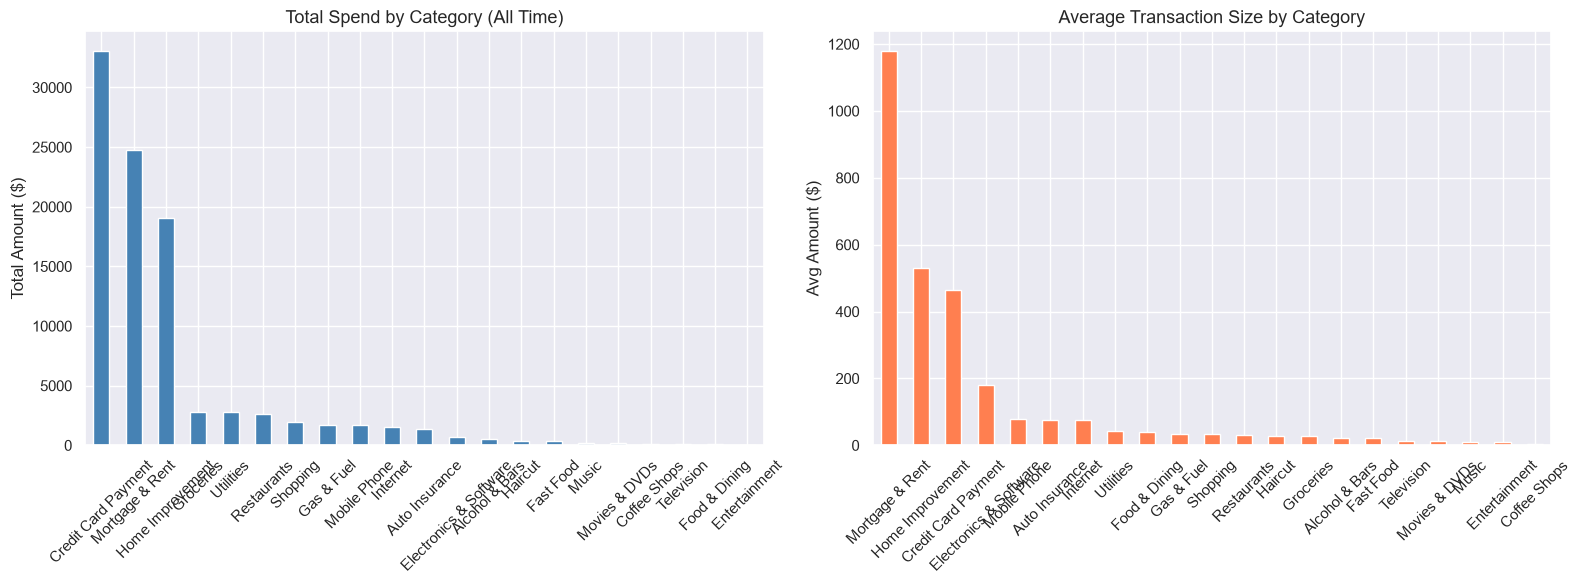

Top 5 categories by total spend:
Category
Credit Card Payment    33041.36
Mortgage & Rent        24754.50
Home Improvement       19092.87
Groceries               2795.21
Utilities               2776.00
Name: Amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total spend per category
cat_spend = debits.groupby('Category')['Amount'].sum().sort_values(ascending=False)
cat_spend.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Spend by Category (All Time)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Amount ($)')
axes[0].tick_params(axis='x', rotation=45)

# Average transaction per category
cat_avg = debits.groupby('Category')['Amount'].mean().sort_values(ascending=False)
cat_avg.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Transaction Size by Category', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/eda_category.png', dpi=150)
plt.show()
print("Top 5 categories by total spend:")
print(cat_spend.head())

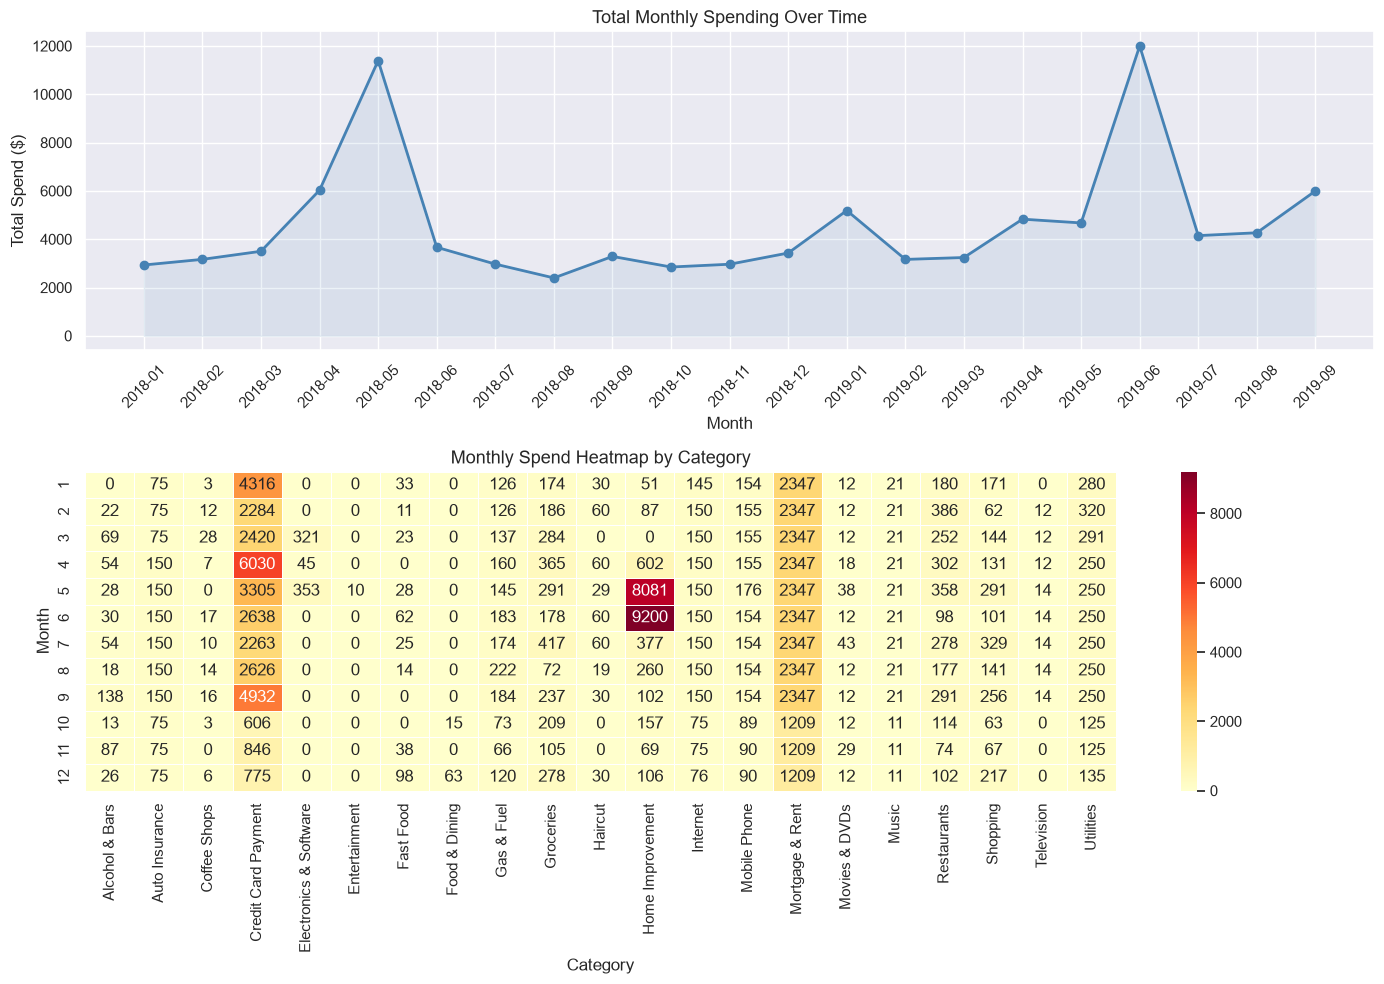

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly total spend
monthly = debits.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[0].plot(monthly['Period'], monthly['Amount'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Total Monthly Spending Over Time', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Spend ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].fill_between(range(len(monthly)), monthly['Amount'], alpha=0.1, color='steelblue')

# Spending heatmap: month vs category
pivot = debits.groupby(['Month', 'Category'])['Amount'].sum().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True, linewidths=0.5)
axes[1].set_title('Monthly Spend Heatmap by Category', fontsize=13)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Month')

plt.tight_layout()
plt.savefig('../data/eda_monthly.png', dpi=150)
plt.show()

In [6]:
# Our ML problem:
# Given: year, month, category → Predict: total spend for that month+category
# This is a regression problem on aggregated monthly data

ml_df = debits.groupby(['Year', 'Month', 'Category'])['Amount'].sum().reset_index()
ml_df.columns = ['Year', 'Month', 'Category', 'MonthlySpend']

# Encode Category as a number (ML models need numbers, not strings)
le = LabelEncoder()
ml_df['CategoryEncoded'] = le.fit_transform(ml_df['Category'])

# Save the encoder — we'll need it in the API later
joblib.dump(le, '../data/label_encoder.pkl')

# Feature engineering: lag features (last month's spend for same category)
ml_df = ml_df.sort_values(['Category', 'Year', 'Month'])
ml_df['PrevMonthSpend'] = ml_df.groupby('Category')['MonthlySpend'].shift(1)
ml_df['PrevPrevMonthSpend'] = ml_df.groupby('Category')['MonthlySpend'].shift(2)
ml_df['RollingAvg3'] = ml_df.groupby('Category')['MonthlySpend'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Drop rows where lag features are NaN (first month per category)
ml_df = ml_df.dropna()

print("ML dataset shape:", ml_df.shape)
print("\nSample:")
ml_df.head(10)

ML dataset shape: (278, 8)

Sample:


,Year,Month,Category,MonthlySpend,CategoryEncoded,PrevMonthSpend,PrevPrevMonthSpend,RollingAvg3
58,2018,5,Alcohol & Bars,27.77,0,19.50,14.00,16.750000
90,2018,7,Alcohol & Bars,35.14,0,27.77,19.50,20.423333
118,2018,9,Alcohol & Bars,65.40,0,35.14,27.77,27.470000
134,2018,10,Alcohol & Bars,12.71,0,65.40,35.14,42.770000
150,2018,11,Alcohol & Bars,86.60,0,12.71,65.40,37.750000
165,2018,12,Alcohol & Bars,26.00,0,86.60,12.71,54.903333
195,2019,2,Alcohol & Bars,8.00,0,26.00,86.60,41.770000
211,2019,3,Alcohol & Bars,49.63,0,8.00,26.00,40.200000
226,2019,4,Alcohol & Bars,54.40,0,49.63,8.00,27.876667
256,2019,6,Alcohol & Bars,30.00,0,54.40,49.63,37.343333


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Updated evaluate function — same as before
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:30s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R²: {r2:.4f}")
    return {'model': model, 'name': name, 'mae': mae, 'rmse': rmse, 'r2': r2, 'preds': preds}

# Model 1 — Linear Regression with scaling
lr_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
results['LinearRegression'] = evaluate_model('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test)

# Model 2 — Ridge with scaling
ridge_pipeline = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
results['Ridge'] = evaluate_model('Ridge Regression', ridge_pipeline, X_train, y_train, X_test, y_test)

# Model 3 — Lasso with scaling
lasso_pipeline = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))])
results['Lasso'] = evaluate_model('Lasso Regression', lasso_pipeline, X_train, y_train, X_test, y_test)

# Models 4, 5, 6 — no scaler needed
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
results['RandomForest'] = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)

xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
results['XGBoost'] = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)

estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42))
]
stacking = StackingRegressor(estimators=estimators, final_estimator=LinearRegression(), cv=5)
results['Stacking'] = evaluate_model('Stacking Ensemble', stacking, X_train, y_train, X_test, y_test)

Linear Regression              | MAE:   110.53 | RMSE:   137.23 | R²: -4.5749
Ridge Regression               | MAE:   110.75 | RMSE:   137.52 | R²: -4.5984
Lasso Regression               | MAE:   110.55 | RMSE:   137.27 | R²: -4.5778
Random Forest                  | MAE:   252.06 | RMSE:   611.97 | R²: -109.8635
XGBoost                        | MAE:   218.68 | RMSE:   481.06 | R²: -67.5077
Stacking Ensemble              | MAE:   255.58 | RMSE:   461.38 | R²: -62.0165


In [12]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# --- Model 2: Ridge Regression ---
# Ridge adds L2 penalty: shrinks all coefficients, never zeroes them
ridge = Ridge(alpha=1.0)
results['Ridge'] = evaluate_model('Ridge Regression', ridge, X_train, y_train, X_test, y_test)

# --- Model 3: Lasso Regression ---
# Lasso adds L1 penalty: can zero out useless features entirely (built-in feature selection)
lasso = Lasso(alpha=0.1)
results['Lasso'] = evaluate_model('Lasso Regression', lasso, X_train, y_train, X_test, y_test)

# --- Model 4: Random Forest ---
# Builds many decision trees on random subsets, averages predictions (bagging)
rf = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
results['RandomForest'] = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)

# --- Model 5: XGBoost ---
# Builds trees sequentially, each correcting the previous one's errors (boosting)
xgb_model = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
results['XGBoost'] = evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test)

# --- Model 6: Stacking Ensemble ---
# Uses RF and XGB as base learners, Linear Regression as meta-learner
# Meta-learner learns HOW to combine the base predictions
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, verbosity=0, random_state=42))
]
stacking = StackingRegressor(estimators=estimators, final_estimator=LinearRegression(), cv=5)
results['Stacking'] = evaluate_model('Stacking Ensemble', stacking, X_train, y_train, X_test, y_test)

Ridge Regression               | MAE:   110.47 | RMSE:   137.16 | R²: -4.5695
Lasso Regression               | MAE:   110.43 | RMSE:   137.13 | R²: -4.5668
Random Forest                  | MAE:   252.06 | RMSE:   611.97 | R²: -109.8635
XGBoost                        | MAE:   218.68 | RMSE:   481.06 | R²: -67.5077
Stacking Ensemble              | MAE:   255.58 | RMSE:   461.38 | R²: -62.0165



=== MODEL COMPARISON ===
           Model  MAE ($)  RMSE ($)        R²
           Lasso   110.43    137.13   -4.5668
           Ridge   110.47    137.16   -4.5695
LinearRegression   110.53    137.23   -4.5749
         XGBoost   218.68    481.06  -67.5077
    RandomForest   252.06    611.97 -109.8635
        Stacking   255.58    461.38  -62.0165


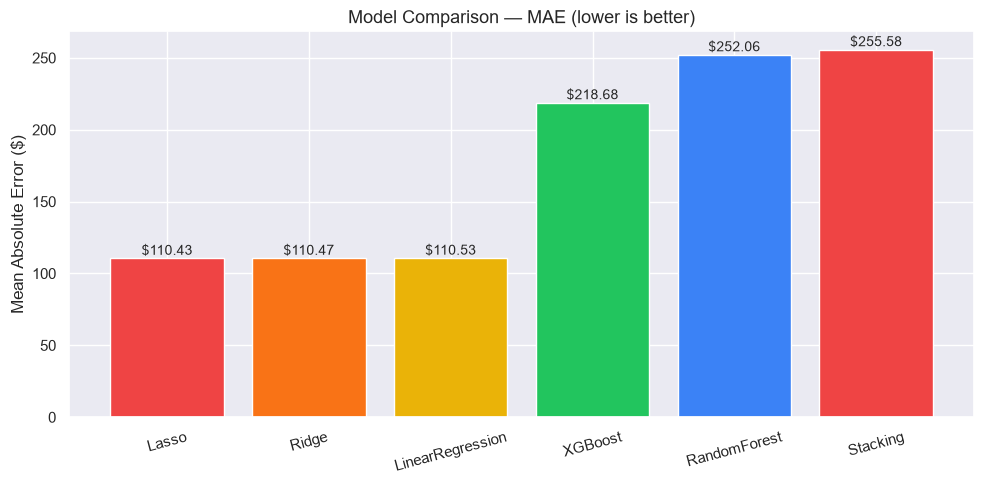


✓ Best model: Lasso with MAE = $110.43


In [13]:
# Build a clean comparison table
comparison = pd.DataFrame([
    {
        'Model': name,
        'MAE ($)': round(r['mae'], 2),
        'RMSE ($)': round(r['rmse'], 2),
        'R²': round(r['r2'], 4)
    }
    for name, r in results.items()
]).sort_values('MAE ($)')

print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
bars = ax.bar(comparison['Model'], comparison['MAE ($)'], color=['#ef4444','#f97316','#eab308','#22c55e','#3b82f6'])
ax.set_title('Model Comparison — MAE (lower is better)', fontsize=13)
ax.set_ylabel('Mean Absolute Error ($)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, comparison['MAE ($)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'${val}', 
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

# Pick best model
best_name = comparison.iloc[0]['Model']
best_model = results[best_name]['model']
print(f"\n✓ Best model: {best_name} with MAE = ${comparison.iloc[0]['MAE ($)']}")

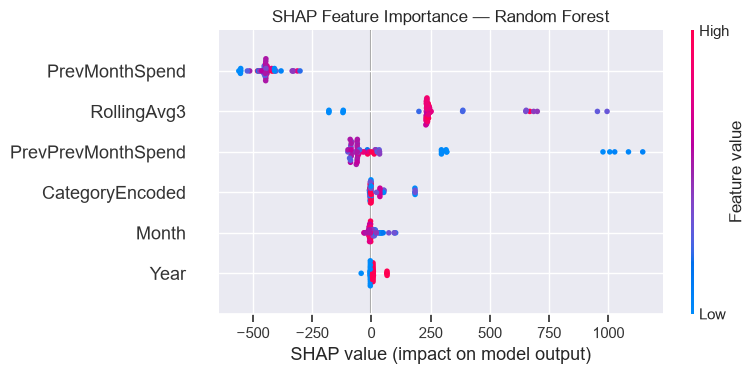

✓ Model saved to ../data/model.pkl
✓ Label encoder saved to ../data/label_encoder.pkl
✓ Feature list saved to ../data/features.pkl
✓ Comparison table saved to ../data/model_comparison.csv

Day 1 + Day 2 complete. Commit your work!


In [14]:
# SHAP tells you: "for this prediction, which features pushed it up or down?"
# Works best with tree-based models
explainer = shap.TreeExplainer(results['RandomForest']['model'])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title('SHAP Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the best model
joblib.dump(best_model, '../data/model.pkl')

# Save feature list (API needs to know the exact feature order)
joblib.dump(features, '../data/features.pkl')

# Save comparison table for the API to serve to frontend
comparison.to_csv('../data/model_comparison.csv', index=False)

print("✓ Model saved to ../data/model.pkl")
print("✓ Label encoder saved to ../data/label_encoder.pkl")
print("✓ Feature list saved to ../data/features.pkl")
print("✓ Comparison table saved to ../data/model_comparison.csv")
print("\nDay 1 + Day 2 complete. Commit your work!")